C:\Users\pingu\anaconda3\Lib\site-packages\fipy\variables\variable.py:1130: RuntimeWarning: invalid value encountered in divide
  return self._BinaryOperatorVariable(lambda a, b: a / b, other)


FiPy: CO2 methanation + RWGS + CO methanation solved.
Outlet center values:
T [K]   = 605.2853413246053
p_CO2 = 7.839638858187955
p_H2  = 6.905059039674948
p_CH4 = 8.36403705924479
p_CO  = 7.9519995387548255


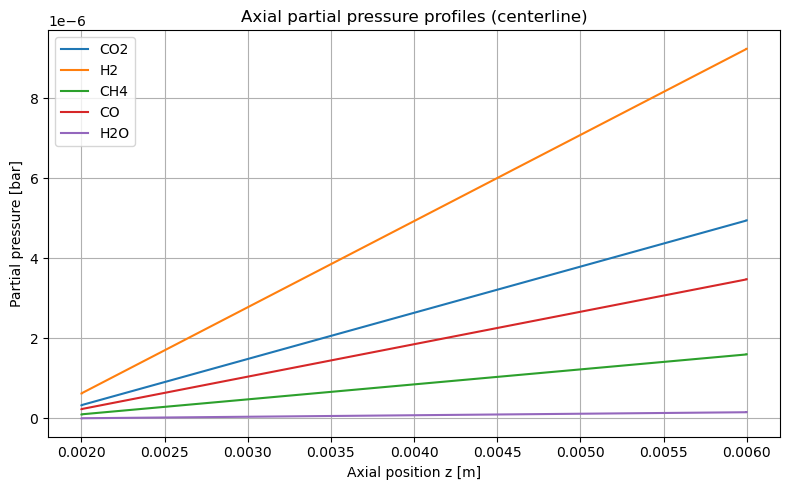

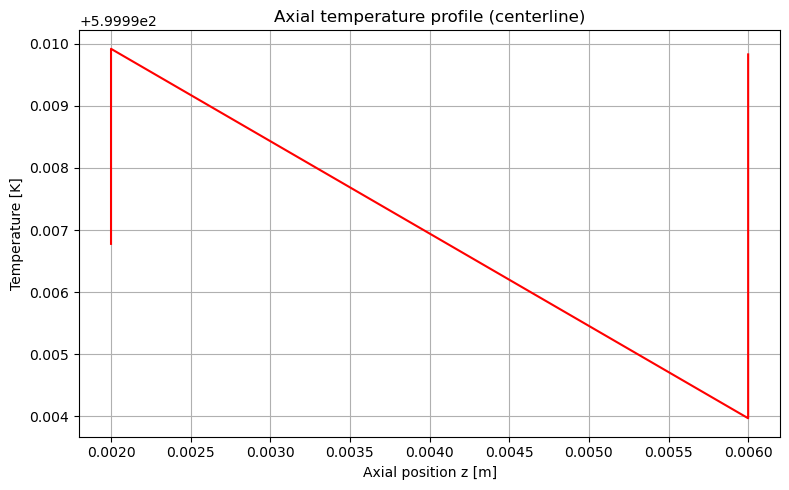

In [3]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt


# ===============================
# Constants
# ===============================
R = 8.314
Rr, Lz = 0.01, 0.2
Nr, Nz = 25, 50
u0 = 0.2
eps, Dr = 0.4, 1e-5
lambda_e = 0.8
rho_b = 1200
Twall = 600

# Stoichiometry
nu = {
    "H2":  [-4, -1, -3],
    "CO2": [-1, -1,  0],
    "CH4": [ 1,  0,  1],
    "H2O": [ 2,  1,  1],
    "CO":  [ 0,  1, -1]
}

dH = [-165e3, 41e3, -206e3]

params = dict(
    k=[1e-3, 5e-4, 8e-4],
    Keq=[1e5, 2e3, 5e4]
)

species = list(nu.keys())

# ===============================
# Mesh
# ===============================
mesh = CylindricalGrid2D(
    dr=Rr/Nr, dz=Lz/Nz, nr=Nr, nz=Nz
)

# ===============================
# Variables
# ===============================
C = {sp: CellVariable(mesh=mesh, value=10.0) for sp in species}
T = CellVariable(mesh=mesh, value=600.0)

# ===============================
# Champom rates
# ===============================
p = {sp: C[sp]*R*T/1e5 for sp in species}

rCO2 = params["k"][0]*p["H2"]**0.5*p["CO2"]**0.5*(1-(p["CH4"]*p["H2O"]**2)/(p["CO2"]*p["H2"]**4*params["Keq"][0]))
rRWGS = params["k"][1]*p["CO2"]*(1-(p["CO"]*p["H2O"])/(p["CO2"]*p["H2"]*params["Keq"][1]))
rCO = params["k"][2]*p["CO"]*p["H2"]**0.5*(1-(p["CH4"]*p["H2O"])/(p["CO"]*p["H2"]**3*params["Keq"][2]))

rates = [rCO2, rRWGS, rCO]

# ===============================
# Species equations
# ===============================
eqs = []
for sp in species:
    Rsp = sum(nu[sp][i]*rates[i] for i in range(3))
    eqs.append(
        TransientTerm(var=C[sp])
        + ConvectionTerm(coeff=(0,u0), var=C[sp])
        ==
        DiffusionTerm(coeff=eps*Dr, var=C[sp])
        + rho_b*Rsp
    )

# ===============================
# Energy equation
# ===============================
energy_eq = (
    TransientTerm(var=T)
    ==
    DiffusionTerm(coeff=lambda_e, var=T)
    + rho_b*sum(-dH[i]*rates[i] for i in range(3))
)

# ===============================
# BCs
# ===============================
for sp in species:
    C[sp].faceGrad.constrain(0, mesh.facesLeft)
    C[sp].faceGrad.constrain(0, mesh.facesRight)

T.faceGrad.constrain(0, mesh.facesLeft)
T.constrain(Twall, mesh.facesRight)

# ===============================
# Solve
# ===============================
dt = 1e-3
for _ in range(300):
    for eq in eqs:
        eq.solve(dt=dt)
    energy_eq.solve(dt=dt)

print("FiPy: CO2 methanation + RWGS + CO methanation solved.")

# ===============================
# Quick inspection (centerline outlet)
# ===============================
print("Outlet center values:")

print("T [K]   =", T.value[-1])
print("p_CO2 =", (C["CO2"].value[-1] * R * T.value[-1] / 1e5))
print("p_H2  =", (C["H2"].value[-1]  * R * T.value[-1] / 1e5))
print("p_CH4 =", (C["CH4"].value[-1] * R * T.value[-1] / 1e5))
print("p_CO  =", (C["CO"].value[-1]  * R * T.value[-1] / 1e5))


# ===============================
# Axial coordinate
# ===============================
z = mesh.cellCenters[1]

def centerline(var):
    """Extract centerline (r≈0) values"""
    return var.value.reshape(Nr, Nz)[0, :]

# ===============================
# Partial pressures
# ===============================
pCO2 = centerline(C["CO2"]) * R * centerline(T) / 1e5
pH2  = centerline(C["H2"])  * R * centerline(T) / 1e5
pCH4 = centerline(C["CH4"]) * R * centerline(T) / 1e5
pCO  = centerline(C["CO"])  * R * centerline(T) / 1e5
pH2O = centerline(C["H2O"]) * R * centerline(T) / 1e5

# ===============================
# Centerline axial profiles (FiPy-safe)
# ===============================

def centerline(var):
    """Extract centerline (r≈0) values"""
    return var.value.reshape(Nr, Nz)[0, :]

# Axial coordinates along centerline
z_center = mesh.cellCenters[1].value.reshape(Nr, Nz)[0, :]

# Partial pressures along centerline
pCO2 = centerline(C["CO2"]) * R * centerline(T) / 1e5
pH2  = centerline(C["H2"])  * R * centerline(T) / 1e5
pCH4 = centerline(C["CH4"]) * R * centerline(T) / 1e5
pCO  = centerline(C["CO"])  * R * centerline(T) / 1e5
pH2O = centerline(C["H2O"]) * R * centerline(T) / 1e5

Tz = centerline(T)

# --- Plot partial pressures ---
plt.figure(figsize=(8,5))
plt.plot(z_center, pCO2, label="CO2")
plt.plot(z_center, pH2,  label="H2")
plt.plot(z_center, pCH4, label="CH4")
plt.plot(z_center, pCO,  label="CO")
plt.plot(z_center, pH2O, label="H2O")
plt.xlabel("Axial position z [m]")
plt.ylabel("Partial pressure [bar]")
plt.title("Axial partial pressure profiles (centerline)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot temperature ---
plt.figure(figsize=(8,5))
plt.plot(z_center, Tz, color="red")
plt.xlabel("Axial position z [m]")
plt.ylabel("Temperature [K]")
plt.title("Axial temperature profile (centerline)")
plt.grid(True)
plt.tight_layout()
plt.show()